In [1]:
import sys                                                                                                                                                                                                                                                                                                                                                                                                                     
import os                                                                                                                                                                                                                                                                                                                                                                                                                      
import torch                                                                                                                                                                                                                                                                                                                                                                                                                   
import numpy as np                                                                                                                                                                                                                                                                                                                                                                                                             
import matplotlib.pyplot as plt                                                                                                                                                                                                                                                                                                                                                                                                
from pathlib import Path                                                                                                                                                                                                                                                                                                                                                                                                       
                                                                                                                                                                                                                                                                                                                                                                                                                                
# Add paths                                                                                                                                                                                                                                                                                                                                                                                                                    
sys.path.insert(0, '/mnt/nas05/data01/francesco/progetto_simone/ionosphere/attri_VAE')                                                                                                                                                                                                                                                                                                                                         
sys.path.insert(0, '/mnt/nas05/data01/francesco/progetto_simone/ionosphere')                                                                                                                                                                                                                                                                                                                                                   
                                                                                                                                                                                                                                                                                                                                                                                                                                
from model.model import UNetVAE                                                                                                                                                                                                                                                                                                                                                                                                
from src.data.dataset import get_sequence_data_objects_iterable

/home2/francesco/.local/lib/python3.10/site-packages/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


In [2]:
# Paths - UPDATE THESE                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                
CSV_PATH = "/mnt/nas05/data01/francesco/progetto_simone/l1_to_map_matched_even_minutes_test_v3_interpolated_deduplicated.csv"                                                                                                                                                                                                                                                                                                  
TRANSFORM_COND_CSV = "/mnt/nas05/data01/francesco/progetto_simone/params.csv"                                                                                                                                                                                                                                                                                                                                                  
                                                                                                                                                                                                                                                                                                                                                                                                                                
# Model config (must match training)                                                                                                                                                                                                                                                                                                                                                                                           
IMG_CHANNELS = 1                                                                                                                                                                                                                                                                                                                                                                                                               
H_DIM = 96                                                                                                                                                                                                                                                                                                                                                                                                                     
LATENT_SIZE = 64                                                                                                                                                                                                                                                                                                                                                                                                               
N_FILTERS_ENC = (8, 16, 32, 64, 16)                                                                                                                                                                                                                                                                                                                                                                                            
N_FILTERS_DEC = (64, 32, 16, 8, 4, 2)                                                                                                                                                                                                                                                                                                                                                                                          
IMG_SIZE = 64                                                                                                                                                                                                                                                                                                                                                                                                                  
                                                                                                                                                                                                                                                                                                                                                                                                                                
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'                                                                                                                                                                                                                                                                                                                                                                        
print(f"Using device: {DEVICE}")    
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
# Load validation dataset                                                                                                                                                                                                                                                                                                                                                                                                      
val_ds, val_sampler, val_loader = get_sequence_data_objects_iterable(                                                                                                                                                                                                                                                                                                                                                          
    csv_path=CSV_PATH,                                                                                                                                                                                                                                                                                                                                                                                                         
    transform_cond_csv=TRANSFORM_COND_CSV,                                                                                                                                                                                                                                                                                                                                                                                     
    batch_size=8,                                                                                                                                                                                                                                                                                                                                                                                                              
    num_data_workers=0,  # 0 for notebook                                                                                                                                                                                                                                                                                                                                                                                      
    split='valid',                                                                                                                                                                                                                                                                                                                                                                                                             
    seed=42,                                                                                                                                                                                                                                                                                                                                                                                                                   
    sequence_length=1,                                                                                                                                                                                                                                                                                                                                                                                                         
    normalization_type='absolute_max',                                                                                                                                                                                                                                                                                                                                                                                         
    use_l1_conditions=True,                                                                                                                                                                                                                                                                                                                                                                                                    
    min_center_distance=30,                                                                                                                                                                                                                                                                                                                                                                                                    
    cartesian_transform=True,                                                                                                                                                                                                                                                                                                                                                                                                  
    output_size=64,                                                                                                                                                                                                                                                                                                                                                                                                            
    only_complete_sequences=True,                                                                                                                                                                                                                                                                                                                                                                                              
    rank=0,                                                                                                                                                                                                                                                                                                                                                                                                                    
    world_size=1,                                                                                                                                                                                                                                                                                                                                                                                                              
)                                                                                                                                                                                                                                                                                                                                                                                                                              
                                                                                                                                                                                                                                                                                                                                                                                                                                
print(f"Validation dataset loaded: {len(val_ds)} sequences")

Using device: cpu
Building L1 conditions cache for valid split...
Cached L1 conditions for 240634 files
Filtered sequences for valid: 1303 -> 1303 (100.0% complete)

COMPUTING EPSILON THRESHOLDS FOR VALID SPLIT
Computed from 1303 sequences:
  Mean:   0.5 GW
  Median: 0.1 GW
  Min:    0.0 GW
  Max:    34.0 GW

Activity thresholds:
  Low (0):    epsilon < 0.0 GW
  Medium (1): 0.0 GW ≤ epsilon < 0.3 GW
  High (2):   epsilon ≥ 0.3 GW

IonoSequenceIterableDataset [valid]: 1303 sequences
  GPU rank: 0/1, Shuffle: True
Validation dataset loaded: 1303 sequences


In [13]:
from attri_VAE.model.model import ConvVAE2D


CHECKPOINT_PATH = "/mnt/nas05/data01/francesco/progetto_simone/results_attri_vae_skipnone_gamma10.0_dropout0.0_hdim96_latentsize64_perceptual0_modelCONVAE2D/Experiment1_WHOLE_betaVAE_mlp_ar_woL1_VarianceMI_onlyVolume_woCapWoAnnealing_epochs500_batchs16_beta2.000000_alpha1.000000_gamma10.000000_factor100.000000_reconparam1_latentsize64_batchsize16/best_test_loss_model.pth"  # UPDATE THIS  
# "\\?\UNC\10.35.146.35\data01\francesco\progetto_simone\results_attri_vae_initialized_datarange01\\best_test_loss_model.pth"

# Initialize model                                                                                                                                                                                                                                                                                                                                                                                                             
# model = UNetVAE(                                                                                                                                                                                                                                                                                                                                                                                                               
#     image_channels=IMG_CHANNELS,                                                                                                                                                                                                                                                                                                                                                                                               
#     h_dim=H_DIM,                                                                                                                                                                                                                                                                                                                                                                                                               
#     latent_size=LATENT_SIZE,                                                                                                                                                                                                                                                                                                                                                                                                   
#     n_filters_ENC=N_FILTERS_ENC,                                                                                                                                                                                                                                                                                                                                                                                               
#     n_filters_DEC=N_FILTERS_DEC,                                                                                                                                                                                                                                                                                                                                                                                               
#     img_size=IMG_SIZE,
#     skip_mode='weighted', skip_dropout_prob=0,
#     skip_scale=0.2                                                                                                                                                                                                                                                                                                                                                                                                        
# )                                                                                                                                                                                                                                                                                                                                                                                                                              

model = ConvVAE2D(image_channels=IMG_CHANNELS, h_dim=H_DIM,                                                                                                                                                                                                                                                                                                                                                           
                    latent_size=LATENT_SIZE, n_filters_ENC=N_FILTERS_ENC,                                                                                                                                                                                                                                                                                                                                                   
                    n_filters_DEC=N_FILTERS_DEC, img_size=64, num_classes=3)   
# Load checkpoint                                                                                                                                                                                                                                                                                                                                                                                                              
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)                                                                                                                                                                                                                                                                                                                                                                  
model.load_state_dict(checkpoint)                                                                                                                                                                                                                                                                                                                                                                                
model = model.to(DEVICE)                                                                                                                                                                                                                                                                                                                                                                                                       
model.eval()                                                                                                                                                                                                                                                                                                                                                                                                                   
                                                                                                                                                                                                                                                                                                                                                                                                                                
# print(f"Model loaded from epoch {checkpoint['epoch']}")                                                                                                                                                                                                                                                                                                                                                                        
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")             

Total parameters: 204,732


In [14]:
# Get one batch                                                                                                                                                                                                                                                                                                                                                                                                                
data_iter = iter(val_loader)                                                                                                                                                                                                                                                                                                                                                                                                   
batch = next(data_iter)                                                                                                                                                                                                                                                                                                                                                                                                        
                                                                                                                                                                                                                                                                                                                                                                                                                                
images = batch[0].squeeze(1).to(DEVICE)  # (batch, 1, H, W)                                                                                                                                                                                                                                                                                                                                                                    
conditions = batch[1].squeeze(1)  # (batch, 4) - normalized conditions                                                                                                                                                                                                                                                                                                                                                         
epsilon = batch[2].squeeze(1)  # epsilon values                                                                                                                                                                                                                                                                                                                                                                                
labels = batch[3].squeeze(1)  # activity labels                                                                                                                                                                                                                                                                                                                                                                                
                                                                                                                                                                                                                                                                                                                                                                                                                                
print(f"Images shape: {images.shape}")                                                                                                                                                                                                                                                                                                                                                                                         
print(f"Conditions shape: {conditions.shape}")                                                                                                                                                                                                                                                                                                                                                                                 
print(f"Image range: [{images.min():.3f}, {images.max():.3f}]")  

Images shape: torch.Size([8, 1, 64, 64])
Conditions shape: torch.Size([8, 4])
Image range: [0.340, 0.619]


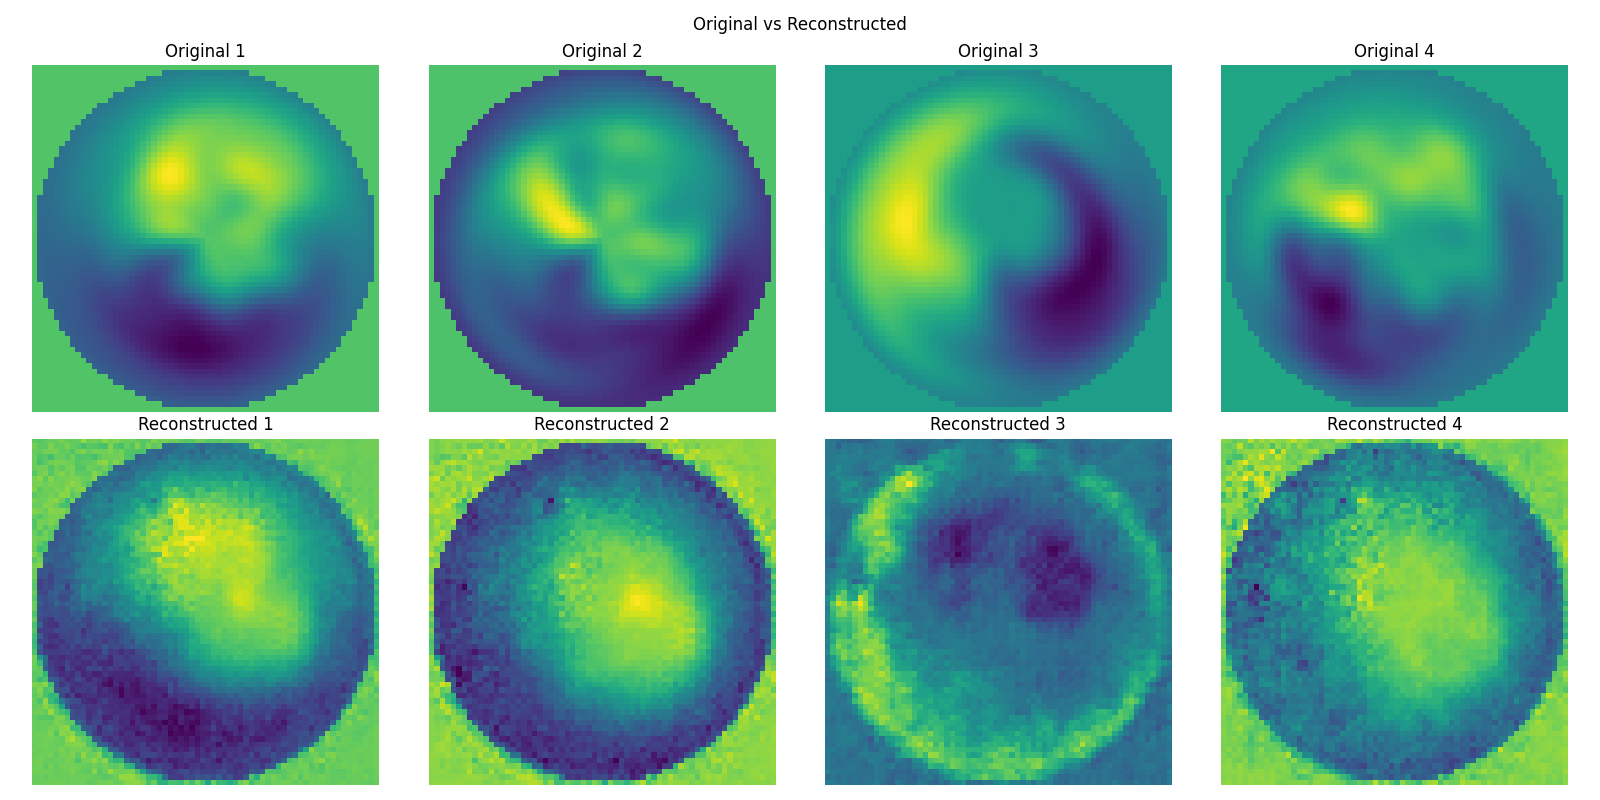

In [15]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image

with torch.no_grad():                                                                                                                                                                                                                                                                                                                                                                                                          
    recon, mu, logvar, out_mlp, z_sampled, z_prior, prior_dist, z_tilde, z_dist = model(images)                                                                                                                                                                                                                                                                                                                                
                                                                                                                                                                                                                                                                                                                                                                                                                                
# Plot original vs reconstructed                                                                                                                                                                                                                                                                                                                                                                                               
fig, axes = plt.subplots(2, 4, figsize=(16, 8))                                                                                                                                                                                                                                                                                                                                                                                
for i in range(4):                                                                                                                                                                                                                                                                                                                                                                                                             
    axes[0, i].imshow(images[i, 0].cpu().numpy(), cmap='viridis')                                                                                                                                                                                                                                                                                                                                                              
    axes[0, i].set_title(f'Original {i+1}')                                                                                                                                                                                                                                                                                                                                                                                    
    axes[0, i].axis('off')                                                                                                                                                                                                                                                                                                                                                                                                     
                                                                                                                                                                                                                                                                                                                                                                                                                                
    axes[1, i].imshow(recon[i, 0].cpu().numpy(), cmap='viridis')                                                                                                                                                                                                                                                                                                                                                               
    axes[1, i].set_title(f'Reconstructed {i+1}')                                                                                                                                                                                                                                                                                                                                                                               
    axes[1, i].axis('off')                                                                                                                                                                                                                                                                                                                                                                                                     
                                                                                                                                                                                                                                                                                                                                                                                                                                
plt.suptitle('Original vs Reconstructed')                                                                                                                                                                                                                                                                                                                                                                                      
plt.tight_layout()                                                                                                                                                                                                                                                                                                                                                                                                             
plt.savefig("/mnt/nas05/data01/francesco/progetto_simone/ionosphere/attri_vae_images_res/example_gen.png")

Image.open("/mnt/nas05/data01/francesco/progetto_simone/ionosphere/attri_vae_images_res/example_gen.png")

In [16]:
# Check latent space statistics for first 4 dimensions (attribute-regularized)                                                                                                                                                                                                                                                                                                                                                 
print("Latent space statistics (first 4 dims = attribute-regularized):")                                                                                                                                                                                                                                                                                                                                                       
print(f"  Dim 0 (bx): mean={mu[:, 0].mean():.3f}, std={mu[:, 0].std():.3f}, range=[{mu[:, 0].min():.3f}, {mu[:, 0].max():.3f}]")                                                                                                                                                                                                                                                                                               
print(f"  Dim 1 (by): mean={mu[:, 1].mean():.3f}, std={mu[:, 1].std():.3f}, range=[{mu[:, 1].min():.3f}, {mu[:, 1].max():.3f}]")                                                                                                                                                                                                                                                                                               
print(f"  Dim 2 (bz): mean={mu[:, 2].mean():.3f}, std={mu[:, 2].std():.3f}, range=[{mu[:, 2].min():.3f}, {mu[:, 2].max():.3f}]")                                                                                                                                                                                                                                                                                               
print(f"  Dim 3 (vx): mean={mu[:, 3].mean():.3f}, std={mu[:, 3].std():.3f}, range=[{mu[:, 3].min():.3f}, {mu[:, 3].max():.3f}]")                                                                                                                                                                                                                                                                                               
                                                                                                                                                                                                                                                                                                                                                                                                                                
# Check correlation with actual conditions                                                                                                                                                                                                                                                                                                                                                                                     
print("\nCorrelation between latent dims and conditions:")                                                                                                                                                                                                                                                                                                                                                                     
for i, name in enumerate(['bx', 'by', 'bz', 'vx']):                                                                                                                                                                                                                                                                                                                                                                            
    corr = np.corrcoef(mu[:, i].cpu().numpy(), conditions[:, i].numpy())[0, 1]                                                                                                                                                                                                                                                                                                                                                 
    print(f"  {name}: {corr:.3f}")              

Latent space statistics (first 4 dims = attribute-regularized):
  Dim 0 (bx): mean=0.033, std=0.613, range=[-0.557, 1.192]
  Dim 1 (by): mean=-0.450, std=0.563, range=[-1.215, 0.242]
  Dim 2 (bz): mean=0.083, std=0.550, range=[-0.993, 0.619]
  Dim 3 (vx): mean=0.351, std=0.766, range=[-0.802, 1.450]

Correlation between latent dims and conditions:
  bx: 0.456
  by: 0.565
  bz: 0.093
  vx: 0.120


In [11]:
def generate_with_attribute_control(model, input_image, target_dim, target_value, device='cpu'):                                                                                                                                                                                                                                                                                                                              
    """                                                                                                                                                                                                                                                                                                                                                                                                                        
    Generate image with controlled attribute value.                                                                                                                                                                                                                                                                                                                                                                            
                                                                                                                                                                                                                                                                                                                                                                                                                                
    Args:                                                                                                                                                                                                                                                                                                                                                                                                                      
        model: trained VAE model                                                                                                                                                                                                                                                                                                                                                                                               
        input_image: input image tensor (1, C, H, W)                                                                                                                                                                                                                                                                                                                                                                           
        target_dim: which dimension to control (0=bx, 1=by, 2=bz, 3=vx)                                                                                                                                                                                                                                                                                                                                                        
        target_value: value to set for that latent dimension                                                                                                                                                                                                                                                                                                                                                                   
    """                                                                                                                                                                                                                                                                                                                                                                                                                        
    model.eval()                                                                                                                                                                                                                                                                                                                                                                                                               
    with torch.no_grad():                                                                                                                                                                                                                                                                                                                                                                                                      
        # Encode to get latent distribution                                                                                                                                                                                                                                                                                                                                                                                    
        mu, logvar, z_dist, x1, x2, x3, x4 = model.encode(input_image.to(device))                                                                                                                                                                                                                                                                                                                                              
                                                                                                                                                                                                                                                                                                                                                                                                                                
        # Use mean (mu) as the latent code                                                                                                                                                                                                                                                                                                                                                                                     
        z = mu.clone()                                                                                                                                                                                                                                                                                                                                                                                                         
                                                                                                                                                                                                                                                                                                                                                                                                                                
        # Modify the specific dimension                                                                                                                                                                                                                                                                                                                                                                                        
        z[:, target_dim] = target_value                                                                                                                                                                                                                                                                                                                                                                                        
                                                                                                                                                                                                                                                                                                                                                                                                                                
        # Decode with modified latent                                                                                                                                                                                                                                                                                                                                                                                          
        # reconstructed = model.decode(z, torch.zeros_like(x1), torch.zeros_like(x2), torch.zeros_like(x3), torch.zeros_like(x4))                                                                                                                                                                                                                                                                                                   
        # Decode with modified latent                                                                                                                                                                                                                                                                                                                                                                                          
        reconstructed = model.decode(z, x1*0.2, x2*0.2, x3*0.2, x4*0.2)                                                                                                                                                                                                                                                                                                                                                                       
                                                                                                                                                                                                                                                                                                                                                                                                                                
    return reconstructed, mu     

In [17]:
####### FOR CONVAE2D MODEL ONLY

def generate_with_attribute_control(model, input_image, target_dim, target_value, device='cpu'):                                                                                                                                                                                                                                                                                                                              
    """                                                                                                                                                                                                                                                                                                                                                                                                                        
    Generate image with controlled attribute value.                                                                                                                                                                                                                                                                                                                                                                            
                                                                                                                                                                                                                                                                                                                                                                                                                                
    Args:                                                                                                                                                                                                                                                                                                                                                                                                                      
        model: trained VAE model                                                                                                                                                                                                                                                                                                                                                                                               
        input_image: input image tensor (1, C, H, W)                                                                                                                                                                                                                                                                                                                                                                           
        target_dim: which dimension to control (0=bx, 1=by, 2=bz, 3=vx)                                                                                                                                                                                                                                                                                                                                                        
        target_value: value to set for that latent dimension                                                                                                                                                                                                                                                                                                                                                                   
    """                                                                                                                                                                                                                                                                                                                                                                                                                        
    model.eval()                                                                                                                                                                                                                                                                                                                                                                                                               
    with torch.no_grad():                                                                                                                                                                                                                                                                                                                                                                                                      
        # Encode to get latent distribution                                                                                                                                                                                                                                                                                                                                                                                    
        mu, logvar, z_dist= model.encode(input_image.to(device))                                                                                                                                                                                                                                                                                                                                              
                                                                                                                                                                                                                                                                                                                                                                                                                                
        # Use mean (mu) as the latent code                                                                                                                                                                                                                                                                                                                                                                                     
        z = mu.clone()                                                                                                                                                                                                                                                                                                                                                                                                         
                                                                                                                                                                                                                                                                                                                                                                                                                                
        # Modify the specific dimension                                                                                                                                                                                                                                                                                                                                                                                        
        z[:, target_dim] = target_value                                                                                                                                                                                                                                                                                                                                                                                        
                                                                                                                                                                                                                                                                                                                                                                                                                                
        # Decode with modified latent                                                                                                                                                                                                                                                                                                                                                                                          
        # reconstructed = model.decode(z, torch.zeros_like(x1), torch.zeros_like(x2), torch.zeros_like(x3), torch.zeros_like(x4))                                                                                                                                                                                                                                                                                                   
        # Decode with modified latent                                                                                                                                                                                                                                                                                                                                                                                          
        reconstructed = model.decode(z)                                                                                                                                                                                                                                                                                                                                                                       
                                                                                                                                                                                                                                                                                                                                                                                                                                
    return reconstructed, mu     

Original latent value for bz: 0.533


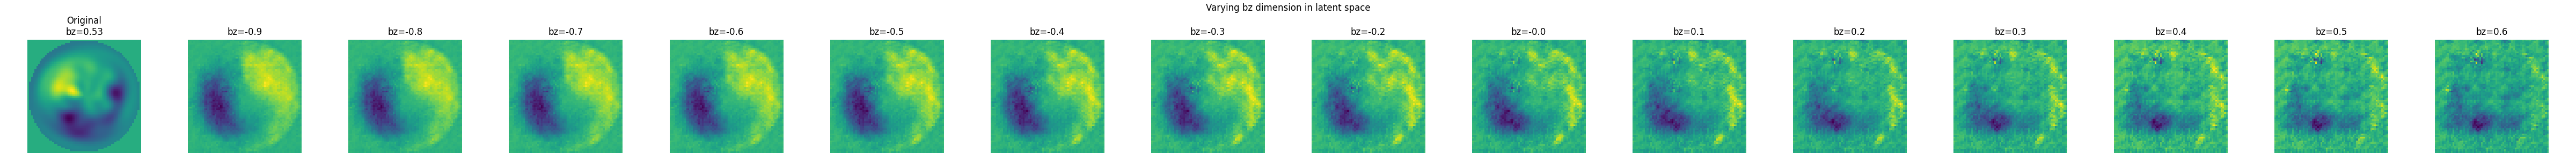

In [25]:
# Pick one image                             
import random
                                                                                                                                                                                                                                                                                                                                                                                  
img_idx = random.randint(0, images.shape[0]-1)                                                                                                                                                                                                                                                                                                                                                                                                                    
input_img = images[img_idx:img_idx+1]                                                                                                                                                                                                                                                                                                                                                                                          
                                                                                                                                                                                                                                                                                                                                                                                                                                
# Vary bz (dimension 2) - often most impactful for ionosphere                                                                                                                                                                                                                                                                                                                                                                  
target_dim = 2  # 0=bx, 1=by, 2=bz, 3=vx                                                                                                                                                                                                                                                                                                                                                                                       
dim_names = ['bx', 'by', 'bz', 'vx']                                                                                                                                                                                                                                                                                                                                                                                           
                                                                                                                                                                                                                                                                                                                                                                                                                                
# Get original latent value for reference                                                                                                                                                                                                                                                                                                                                                                                      
with torch.no_grad():                                                                                                                                                                                                                                                                                                                                                                                                          
    mu_orig, *_ = model.encode(input_img)                                                                                                                                                                                                                                                                                                                                                                                      
    original_value = mu_orig[0, target_dim].item()                                                                                                                                                                                                                                                                                                                                                                             
                                                                                                                                                                                                                                                                                                                                                                                                                                
print(f"Original latent value for {dim_names[target_dim]}: {original_value:.3f}")                                                                                                                                                                                                                                                                                                                                              
                                                                                                                                                                                                                                                                                                                                                                                                                                
# Vary the attribute                                                                                                                                                                                                                                                                                                                                                                                                           
values = np.linspace(-0.9, 0.6, 15)                                                                                                                                                                                                                                                                                                                                                                                                 
fig, axes = plt.subplots(1, len(values) + 1, figsize=(3 * (len(values) + 1), 3))                                                                                                                                                                                                                                                                                                                                               
                                                                                                                                                                                                                                                                                                                                                                                                                                
# Original                                                                                                                                                                                                                                                                                                                                                                                                                     
axes[0].imshow(input_img[0, 0].cpu().numpy(), cmap='viridis')                                                                                                                                                                                                                                                                                                                                                                  
axes[0].set_title(f'Original\n{dim_names[target_dim]}={original_value:.2f}')                                                                                                                                                                                                                                                                                                                                                   
axes[0].axis('off')                                                                                                                                                                                                                                                                                                                                                                                                            
                                                                                                                                                                                                                                                                                                                                                                                                                                
# Variations                                                                                                                                                                                                                                                                                                                                                                                                                   
for i, val in enumerate(values):                                                                                                                                                                                                                                                                                                                                                                                               
    output, _ = generate_with_attribute_control(model, input_img, target_dim, val)                                                                                                                                                                                                                                                                                                                                             
    axes[i + 1].imshow(output[0, 0].cpu().numpy(), cmap='viridis')                                                                                                                                                                                                                                                                                                                                                             
    axes[i + 1].set_title(f'{dim_names[target_dim]}={val:.1f}')                                                                                                
                                                                                                                                                                                                                                                                    
    axes[i + 1].axis('off')                                                                                                                                                                                                                                                                                                                                                                                                    
                                                                                                                                                                                                                                                                                                                                                                                                                                
plt.suptitle(f'Varying {dim_names[target_dim]} dimension in latent space')                                                                                                                                                                                                                                                                                                                                                     
plt.tight_layout()                                                                                                                                                                                                                                                                                                                                                                                                             
plt.savefig("/mnt/nas05/data01/francesco/progetto_simone/ionosphere/attri_vae_images_res/example_control.png")

Image.open("/mnt/nas05/data01/francesco/progetto_simone/ionosphere/attri_vae_images_res/example_control.png") 

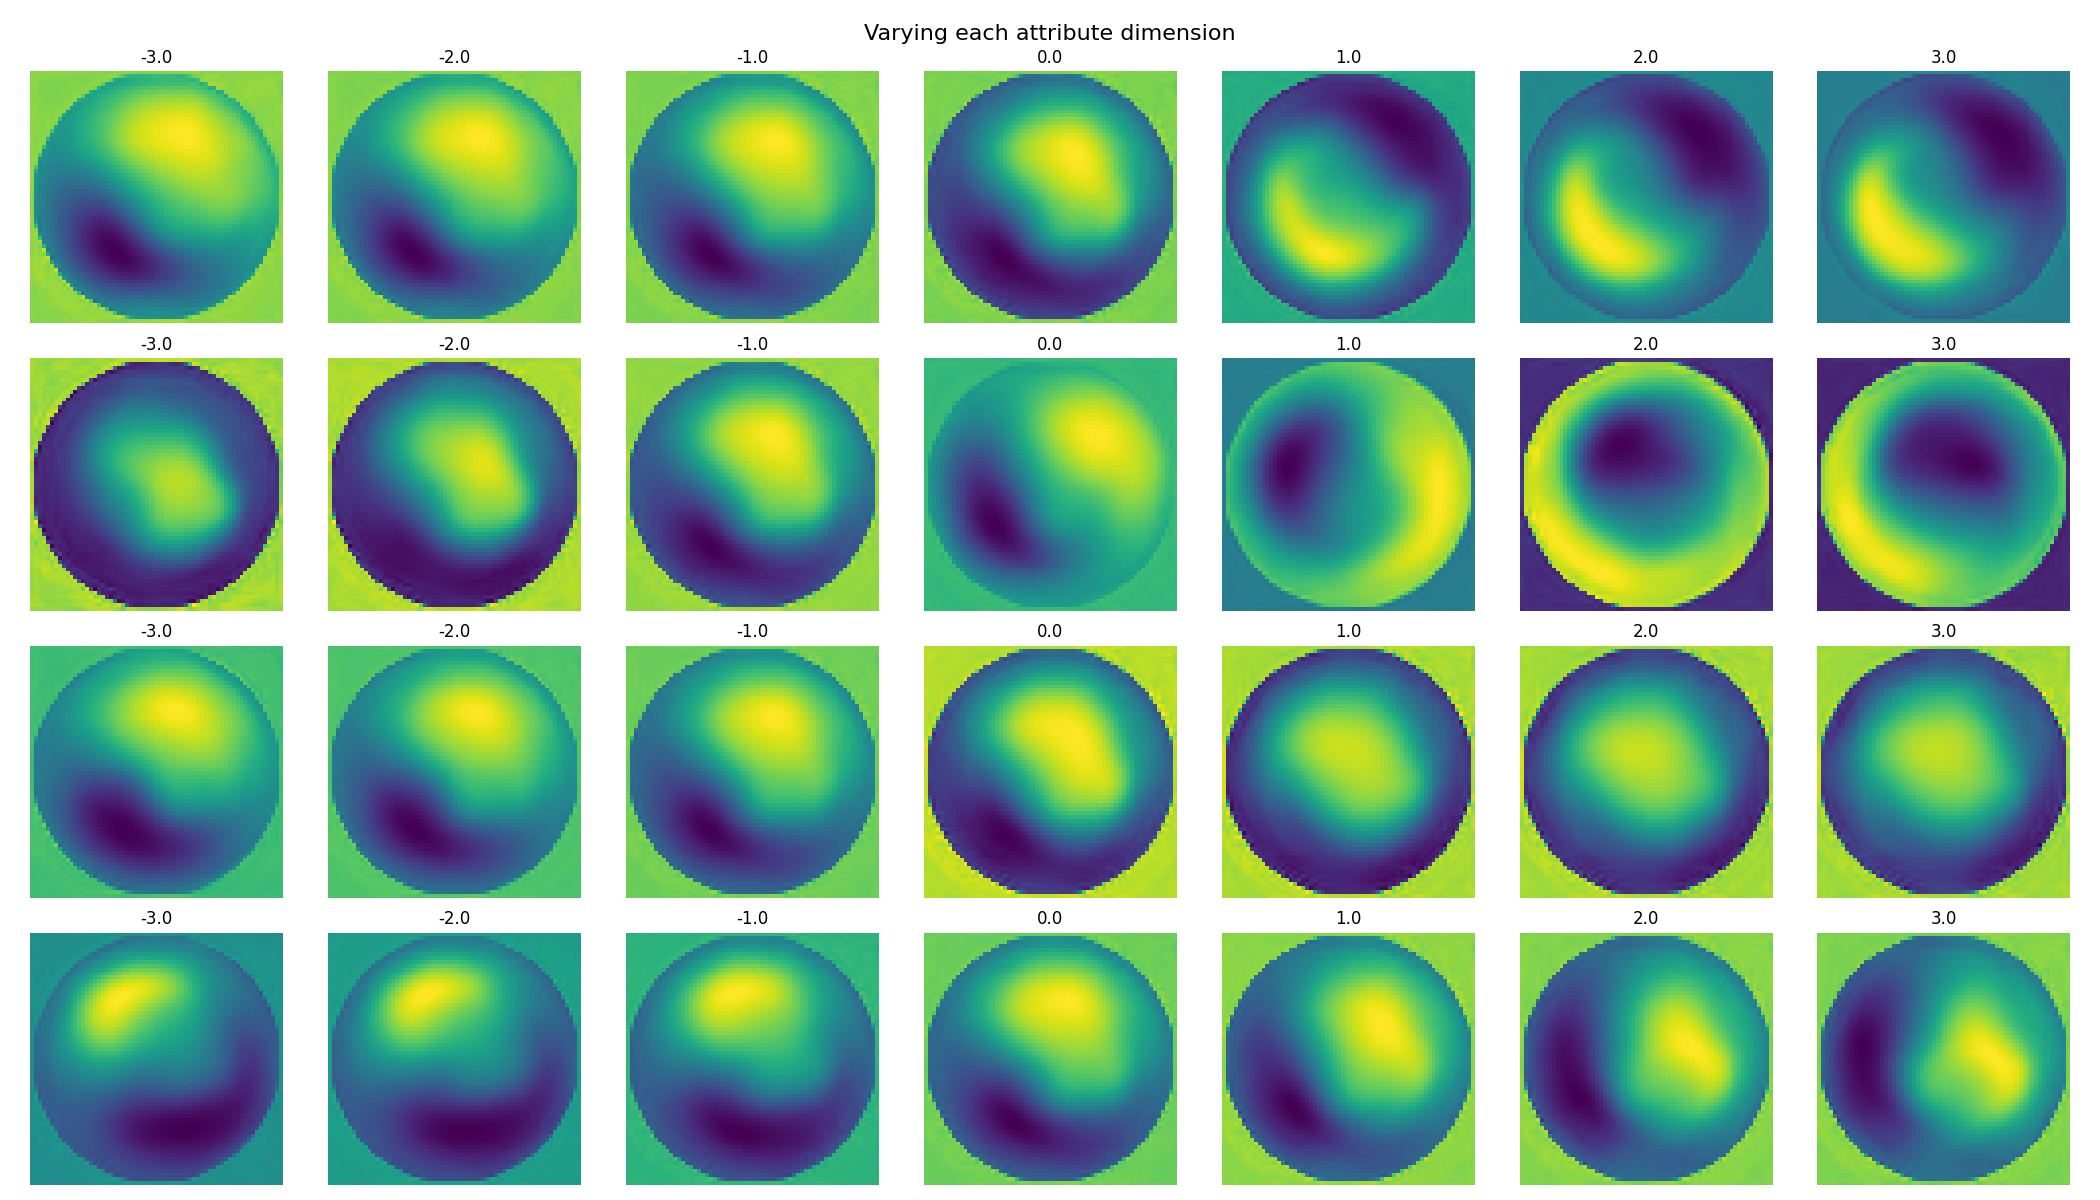

In [26]:
# Vary all 4 attribute dimensions for comparison                                                                                                                                                                                                                                                                                                                                                                               
img_idx = 0                                                                                                                                                                                                                                                                                                                                                                                                                    
input_img = images[img_idx:img_idx+1]                                                                                                                                                                                                                                                                                                                                                                                          
dim_names = ['bx', 'by', 'bz', 'vx']                                                                                                                                                                                                                                                                                                                                                                                           
                                                                                                                                                                                                                                                                                                                                                                                                                                
fig, axes = plt.subplots(4, 7, figsize=(21, 12))                                                                                                                                                                                                                                                                                                                                                                               
values = np.linspace(-3, 3, 7)                                                                                                                                                                                                                                                                                                                                                                                                 
                                                                                                                                                                                                                                                                                                                                                                                                                                
for dim in range(4):                                                                                                                                                                                                                                                                                                                                                                                                           
    for i, val in enumerate(values):                                                                                                                                                                                                                                                                                                                                                                                           
        output, _ = generate_with_attribute_control(model, input_img, dim, val)                                                                                                                                                                                                                                                                                                                                                
        axes[dim, i].imshow(output[0, 0].cpu().numpy(), cmap='viridis')                                                                                                                                                                                                                                                                                                                                                        
        axes[dim, i].set_title(f'{val:.1f}')                                                                                                                                                                                                                                                                                                                                                                                   
        axes[dim, i].axis('off')                                                                                                                                                                                                                                                                                                                                                                                               
                                                                                                                                                                                                                                                                                                                                                                                                                                
    axes[dim, 0].set_ylabel(dim_names[dim], fontsize=14, rotation=0, labelpad=30)                                                                                                                                                                                                                                                                                                                                              
                                                                                                                                                                                                                                                                                                                                                                                                                                
plt.suptitle('Varying each attribute dimension', fontsize=16)                                                                                                                                                                                                                                                                                                                                                                  
plt.tight_layout()                                                                                                                                                                                                                                                                                                                                                                                                             
plt.savefig("/mnt/nas05/data01/francesco/progetto_simone/ionosphere/attri_vae_images_res/example_control_all4.png")

Image.open("/mnt/nas05/data01/francesco/progetto_simone/ionosphere/attri_vae_images_res/example_control_all4.png") 

In [10]:
# Collect latent statistics over more samples                                                                                                                                                                                                                                                                                                                                                                                  
all_mu = []                                                                                                                                                                                                                                                                                                                                                                                                                    
all_cond = []                                                                                                                                                                                                                                                                                                                                                                                                                  
                                                                                                                                                                                                                                                                                                                                                                                                                                
model.eval()                                                                                                                                                                                                                                                                                                                                                                                                                   
with torch.no_grad():                                                                                                                                                                                                                                                                                                                                                                                                          
    for i, batch in enumerate(val_loader):                                                                                                                                                                                                                                                                                                                                                                                     
        if i >= 50:  # Limit to 50 batches                                                                                                                                                                                                                                                                                                                                                                                     
            break                                                                                                                                                                                                                                                                                                                                                                                                              
        imgs = batch[0].squeeze(1).to(DEVICE)                                                                                                                                                                                                                                                                                                                                                                                  
        conds = batch[1].squeeze(1)                                                                                                                                                                                                                                                                                                                                                                                            
                                                                                                                                                                                                                                                                                                                                                                                                                                
        mu, *_ = model.encode(imgs)                                                                                                                                                                                                                                                                                                                                                                                            
        all_mu.append(mu[:, :4].cpu())                                                                                                                                                                                                                                                                                                                                                                                         
        all_cond.append(conds)                                                                                                                                                                                                                                                                                                                                                                                                 
                                                                                                                                                                                                                                                                                                                                                                                                                                
all_mu = torch.cat(all_mu, dim=0)                                                                                                                                                                                                                                                                                                                                                                                              
all_cond = torch.cat(all_cond, dim=0)                                                                                                                                                                                                                                                                                                                                                                                          
                                                                                                                                                                                                                                                                                                                                                                                                                                
print(f"Collected {len(all_mu)} samples")                                                                                                                                                                                                                                                                                                                                                                                      
print("\nLatent statistics (attribute dimensions):")                                                                                                                                                                                                                                                                                                                                                                           
for i, name in enumerate(['bx', 'by', 'bz', 'vx']):                                                                                                                                                                                                                                                                                                                                                                            
    print(f"  {name}: min={all_mu[:, i].min():.2f}, max={all_mu[:, i].max():.2f}, "                                                                                                                                                                                                                                                                                                                                            
        f"mean={all_mu[:, i].mean():.2f}, std={all_mu[:, i].std():.2f}")                                                                                                                                                                                                                                                                                                                                                     
                                                                                                                                                                                                                                                                                                                                                                                                                                
print("\nCorrelations (latent vs condition):")                                                                                                                                                                                                                                                                                                                                                                                 
for i, name in enumerate(['bx', 'by', 'bz', 'vx']):                                                                                                                                                                                                                                                                                                                                                                            
    corr = np.corrcoef(all_mu[:, i].numpy(), all_cond[:, i].numpy())[0, 1]                                                                                                                                                                                                                                                                                                                                                     
    print(f"  {name}: r = {corr:.3f}")    

Collected 400 samples

Latent statistics (attribute dimensions):
  bx: min=-0.75, max=1.41, mean=0.15, std=0.61
  by: min=-1.74, max=1.62, mean=-0.20, std=0.91
  bz: min=-1.81, max=1.45, mean=0.06, std=0.89
  vx: min=-0.36, max=0.42, mean=0.04, std=0.17

Correlations (latent vs condition):
  bx: r = 0.381
  by: r = 0.529
  bz: r = 0.516
  vx: r = 0.049
